In [ ]:
import numpy as np
import pandas as pd
# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
# For saving models
import pickle

In [2]:
original = pd.read_csv(r'C:\Users\andre\.cache\kagglehub\datasets\tohidkhanbagani\salifort-dataset\versions\1\HR_Sailfort_dataset.csv')

In [3]:
# Creating a copy to save the original in case I need to come back to it later

data = original.copy()

In [4]:
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
# data.columns

In [6]:
# There are mistakes in the column names and the formatting is different

# Renaming columns: 
# 'Work_accident' --> 'work_accident'; 
# 'number_project' --> 'number_of_projects';
# 'average_montly_hours' --> 'average_monthly_hours'
# 'Department' --> 'department'

data.columns = ['satisfaction_level', 'last_evaluation', 'number_of_projects',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary']

In [7]:
data.head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [8]:
data.shape

(14999, 10)

In [9]:
# Checking for missing values

data.isna().sum()

satisfaction_level       0
last_evaluation          0
number_of_projects       0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

In [10]:
# Checking for duplicates

data.duplicated().sum()

3008

In [11]:
# Out of almost 15,000 entries around 3,000 are duplicates, which seems to be a high proportion
# 
# Check if the duplicated entries are legitimate data or ended up in the dataset by mistake

data[data.duplicated()].head()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [12]:
# It seems unlikely that two entries could be exactly the same, especially given 
# the evaluation scores and satisfaction levels being a percentage, so it is save to drop them
#
# Dropping the duplicates

data.drop_duplicates(inplace=True)

In [13]:
# Number of entries after dropping duplicates is down to just under 12,000

data.shape

(11991, 10)

In [14]:
# Checking the number and the percent of employees who stayed and who left

print('# of stayed/left')
print(data.left.value_counts())
print('')
print('% of stayed/left')
print(data.left.value_counts(normalize=True)*100)

# of stayed/left
left
0    10000
1     1991
Name: count, dtype: int64

% of stayed/left
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


In [15]:
# Descriptive statistics of all the employees

data.describe()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Some notable observations:
- Most of the employees are quite satisfied (average 0.63) however there are also some who are not satisfied at all (min 0.09) - satisfaction might be one of the reasons to leave, however there might be other reasons that influence satisfaction;
- On average employees work around 200 hours per month, however there are some who work up to 310 hours per month - this might be one of the reasons that influences satisfaction
- Very few got promoted in the last 5 years - around 2% of all the employees - another possible reason of discontent and lower satisfaction levels, especially if they stayed for long time in the company


In [16]:
# Boolean mask for stayed / left

stayed = (data['left'] == 0)
left = (data['left'] == 1)

In [17]:
# Descriptive statistics of those who stayed


data[stayed].describe()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000
mean,0.667365,0.715667,3.786800,198.942700,3.262000,0.174500,0.0,0.019500
std,0.217082,0.161919,0.981755,45.665507,1.367239,0.379558,0.0,0.138281
min,0.120000,0.360000,2.000000,96.000000,2.000000,0.000000,0.0,0.000000
25%,0.540000,0.580000,3.000000,162.000000,2.000000,0.000000,0.0,0.000000
50%,0.690000,0.710000,4.000000,198.000000,3.000000,0.000000,0.0,0.000000
75%,0.840000,0.850000,4.000000,238.000000,4.000000,0.000000,0.0,0.000000
max,1.000000,1.000000,6.000000,287.000000,10.000000,1.000000,0.0,1.000000


In [18]:
# Descriptive statistics of those who left

data[left].describe()

,satisfaction_level,last_evaluation,number_of_projects,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years
count,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.000000,1991.0,1991.000000
mean,0.440271,0.721783,3.883476,208.162230,3.881467,0.052737,1.0,0.004018
std,0.265207,0.197436,1.817139,61.295145,0.974041,0.223565,0.0,0.063277
min,0.090000,0.450000,2.000000,126.000000,2.000000,0.000000,1.0,0.000000
25%,0.110000,0.520000,2.000000,146.000000,3.000000,0.000000,1.0,0.000000
50%,0.410000,0.790000,4.000000,226.000000,4.000000,0.000000,1.0,0.000000
75%,0.730000,0.910000,6.000000,262.500000,5.000000,0.000000,1.0,0.000000
max,0.920000,1.000000,7.000000,310.000000,6.000000,1.000000,1.0,1.000000


Comparing separate stats tables of employees who stayed vs those who left shows that:
- Among those who left satisfaction scores on average is lower
- On average those who left worked 10 hours longer than those who stayed
- Out of those who stayed more had work accidents than of those who left - it indicates that work accidents do not contribute to people leaving the company  

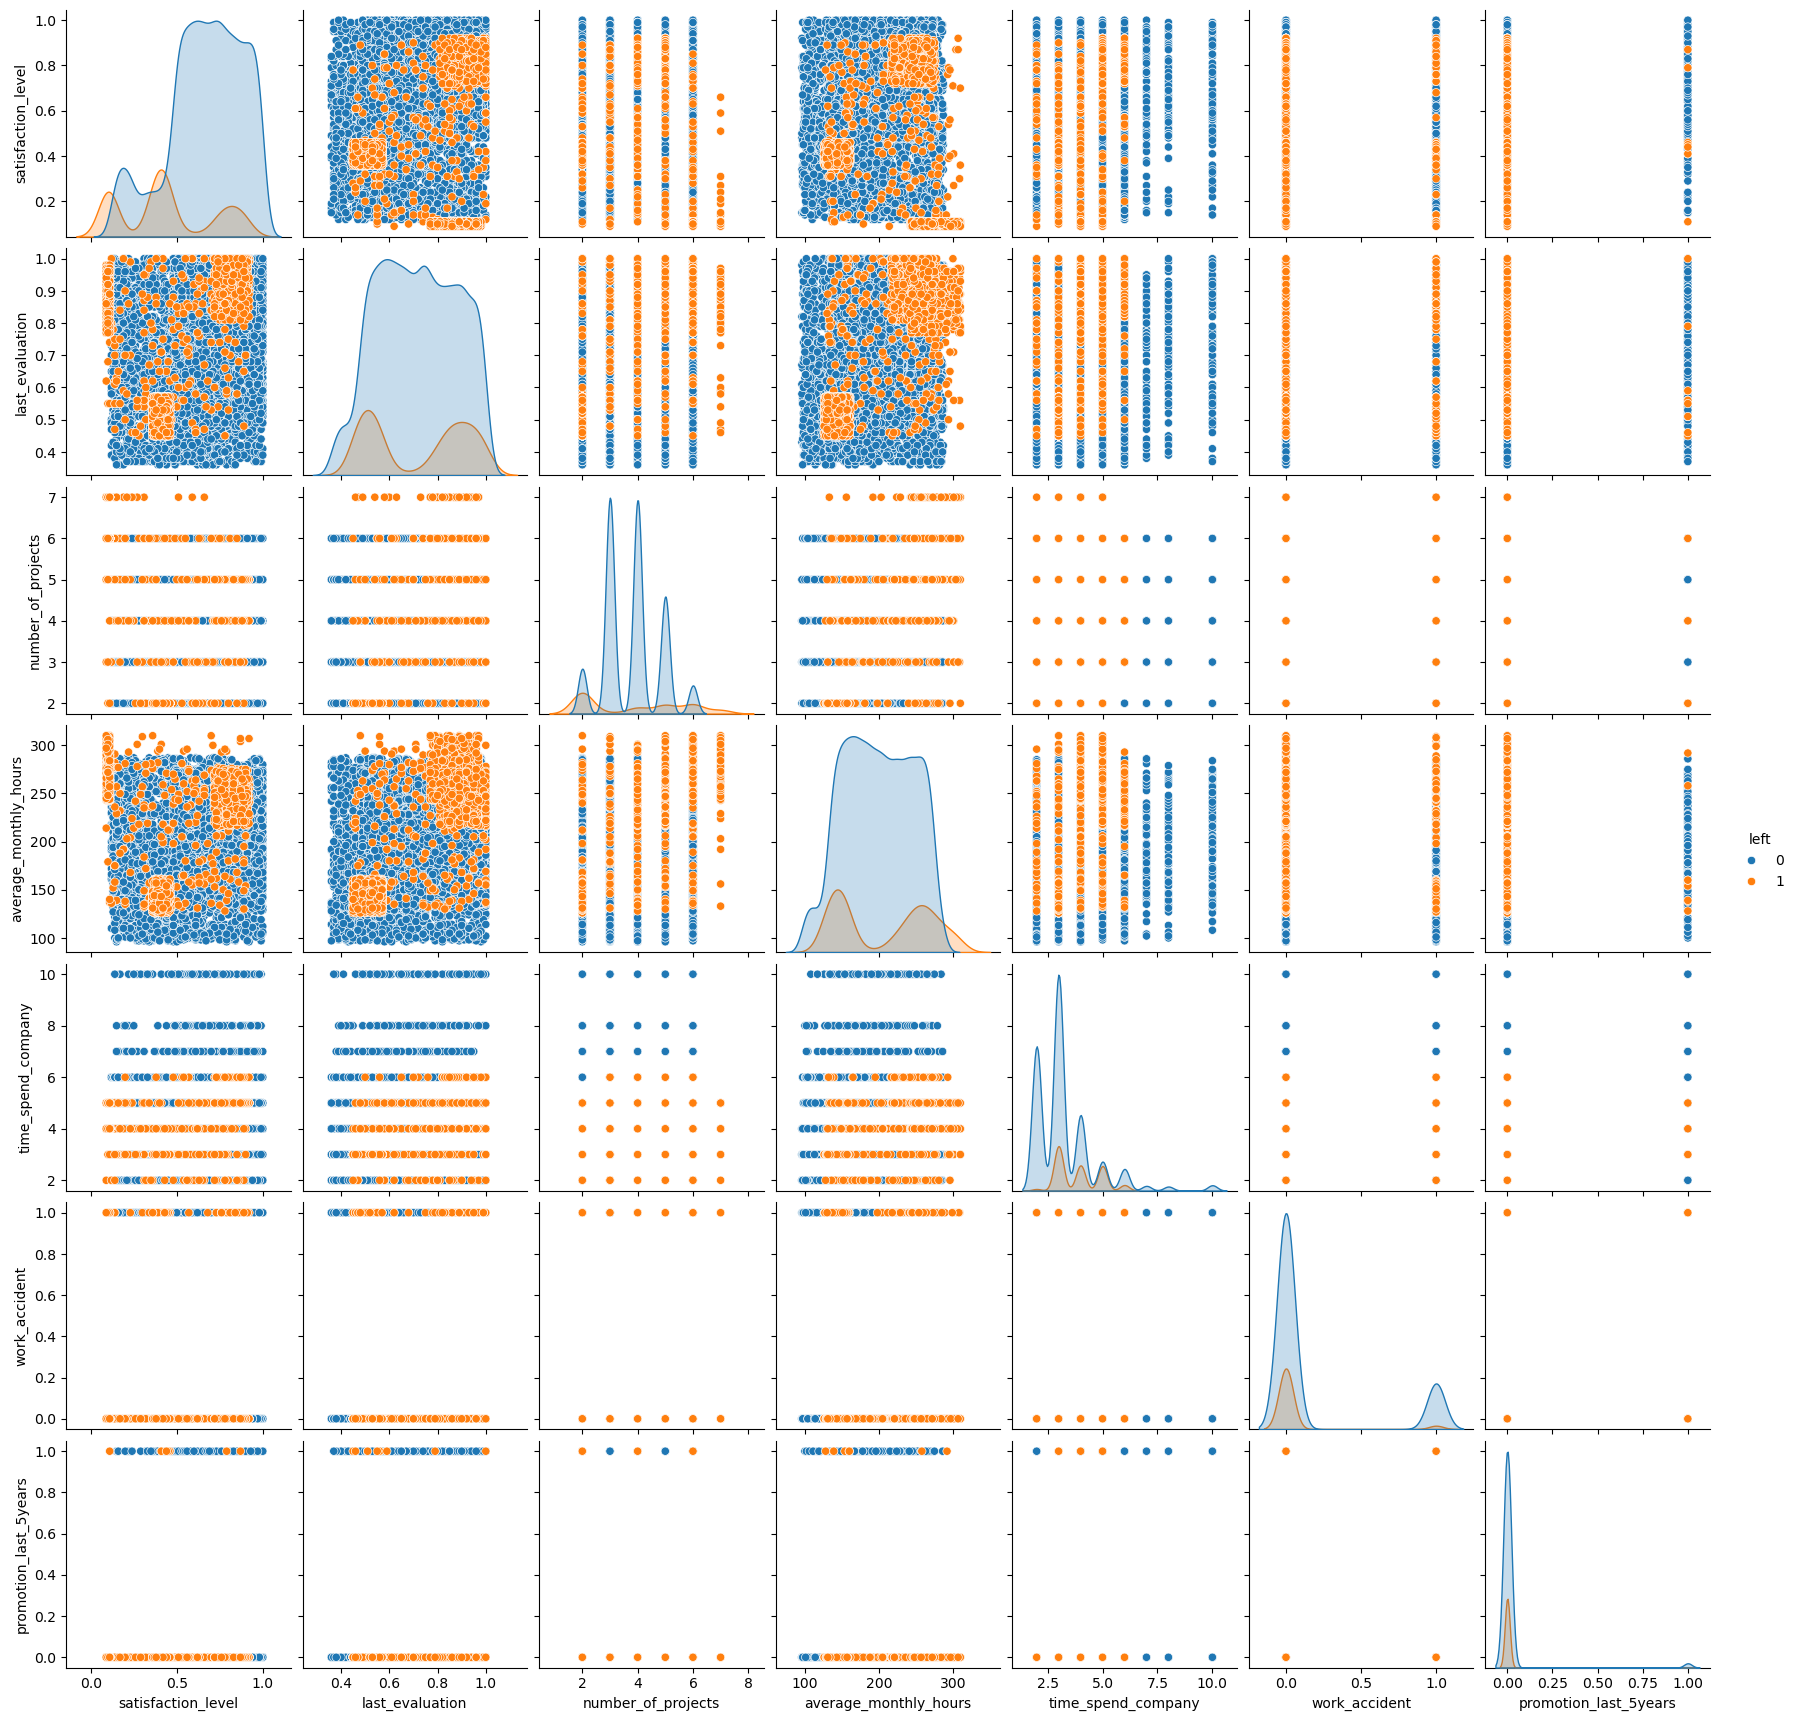

In [183]:
# Scatter plots to look for trends, patterns and clusters

sns.pairplot(data.sort_values('left'), hue='left')

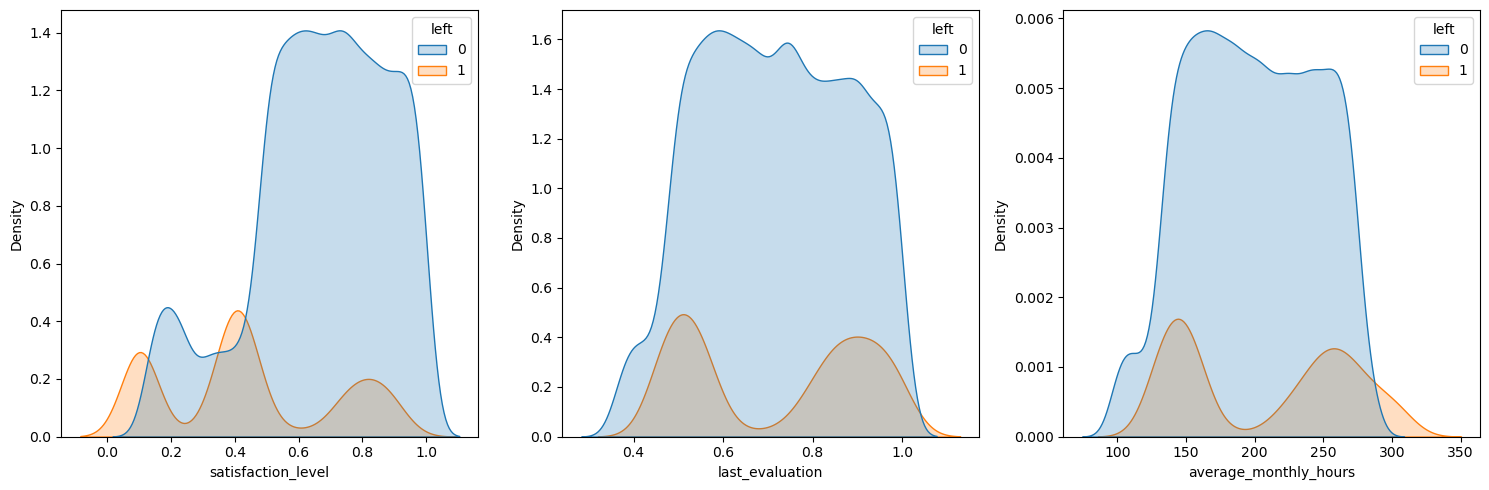

In [19]:
# Let's look at some of the plots closer

fig, ax = plt.subplots(1,3,figsize=(15, 5))

kde_columns = ['satisfaction_level','last_evaluation','average_monthly_hours']

for i, column in enumerate(kde_columns):
    sns.kdeplot(data=data, x=column, color='blue', hue='left', fill=True, ax=ax[i])

plt.tight_layout()
plt.show()

In each metric, there are groups of people who left

1. Satisfaction - not satisfied, moderately satisfied and satisfied employees
2. Evaluation - moderately appreciated and highly appreciated workers
3. Monthly hours - those who work around 150h and those around 260h

The biggest concern for the company should be the fact that highly skilled an appreciated workers are leaving, one of the reasons might be overworking. 


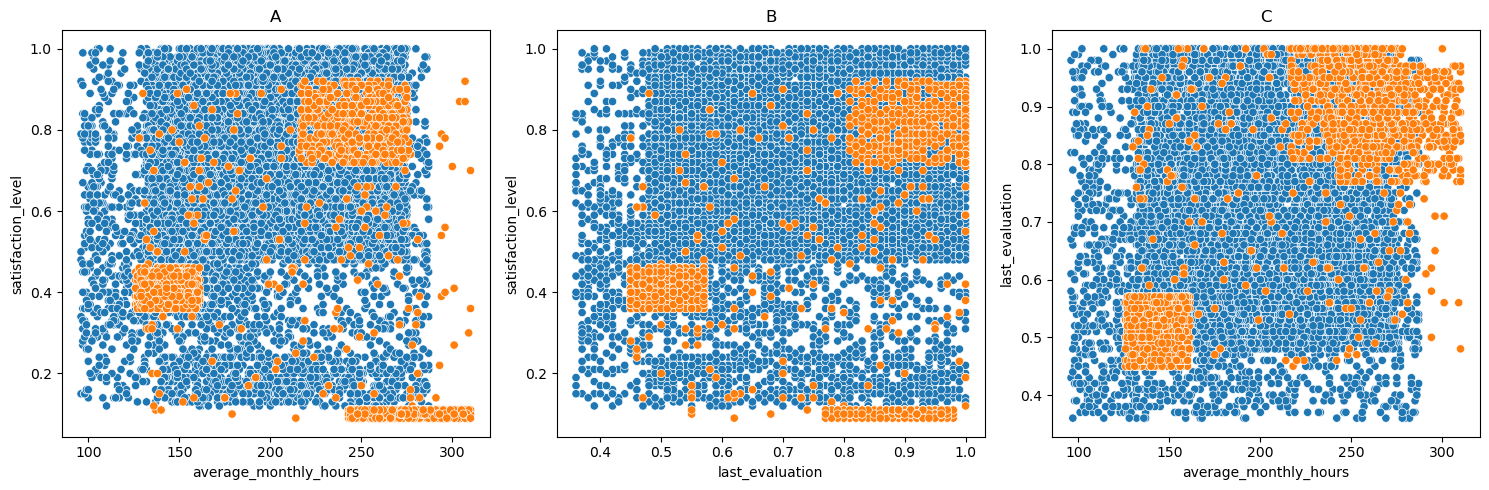

In [ ]:
# Scatter plots of the three metrics mentioned above

fig,ax= plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(data=data.sort_values('left'), x='average_monthly_hours', y='satisfaction_level', hue='left', ax=ax[0], legend=None)
ax[0].set_title('A')

sns.scatterplot(data=data.sort_values('left'), x='last_evaluation', y='satisfaction_level', hue='left', ax=ax[1],legend=None)
ax[1].set_title('B')

sns.scatterplot(data=data.sort_values('left'), x='average_monthly_hours', y='last_evaluation', hue='left', ax=ax[2],legend=None)
ax[2].set_title('C')



plt.tight_layout()
plt.show()

The plots A and B reveal that there are employees who left who worked from 240 and up to 310 hours per month, they were highly evaluated workers. It is highly probable that potential reason for them leaving is overworking.  

Another group from plots A and B are workers who left who worked from 210 to 260 hours who are very well evaluated and who seem to be satisfied. It is unclear why they left however I suppose it has to do with not getting a promotion, we can check it later.

In the plot C the two groups mentioned above converge into one in the right upper corner of employees who worked a lot and were well evaluated.

A third group that can be seen on all of the three plots are employees who worked little, were dissatisfied and were not evaluated well. Here the assumption might be that either those employees were fired for the lack of effort and efficiency, or that those who were already planning to leave reduced their working hours and efficiency.


([<matplotlib.axis.XTick at 0x1c60005ffb0>,
 [Text(0, 0, 'not promoted'), Text(1, 0, 'promoted')])

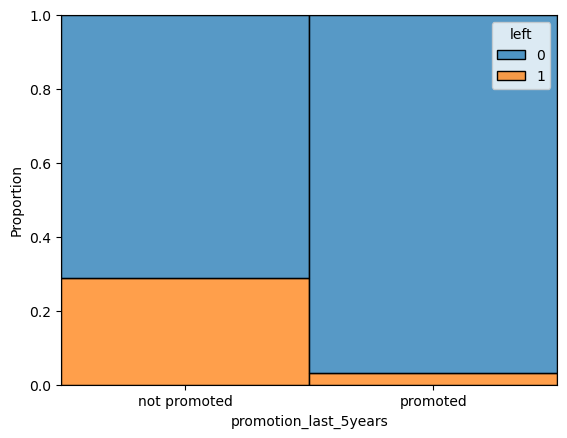

In [21]:
# Checking the promotion theory

high_satisfaction = data['satisfaction_level'] > 0.6

overworked = data['average_monthly_hours'] > 210

well_evaluated = data['last_evaluation'] > 0.75

sns.histplot(data=data[high_satisfaction & overworked & well_evaluated], x='promotion_last_5years', hue='left', multiple='fill', stat='proportion', discrete=True)

plt.xticks(ticks=[0,1],labels=['not promoted', 'promoted'])


In [35]:
print('Percent out ALL of employees who left ' + str(data.left.value_counts(normalize=True).loc[1]*100) + '%')
print('')
print('Percent out SATISFIED, OVERWORKED and WELL EVALUATED employees who left ' + str(data[high_satisfaction & overworked & well_evaluated].left.value_counts(normalize=True).loc[1]*100)+ '%')


Percent out ALL of employees who left 16.604119756484028%

Percent out SATISFIED, OVERWORKED and WELL EVALUATED employees who left 28.40068298235629%


It could be a potential reason that for some people it is important to get recognized for their efforts, and data provide some evidence (however not so strong)

The proportion of employees leaving is about 12 percentage points higher among those who are satisfied, overworked and well evaluated compared to the proportion of leaving employees out of all the employees.



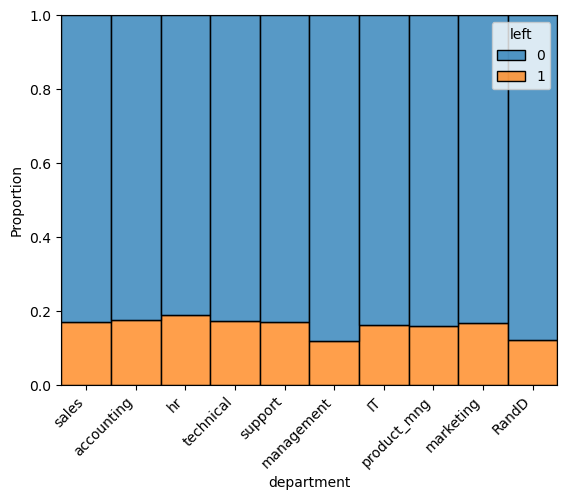

In [ ]:
# Is any department losing more employees than others?
#
# No, the proportion of those who left in each department is close to the overal proportion of 16.6%

sns.histplot(data=data, x='department', hue='left', multiple='fill', stat='proportion')
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

<Axes: xlabel='time_spend_company', ylabel='Proportion'>

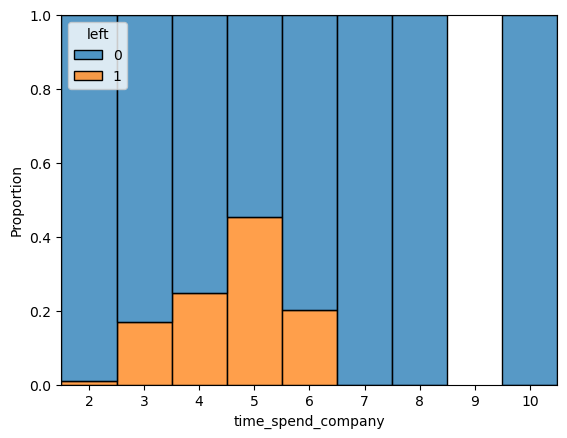

In [ ]:
# After how many years in the company do employees leave?
# 
# Employees who stayed between 3 and 6 years have significantly higher proportions of those who left compared to others. 
# Proprorton of leaving employees among those who spent 5 years in the company is close to 50%


sns.histplot(data=data, x='time_spend_company', hue='left', multiple='fill', stat='proportion', discrete=True)

In [22]:
years_spent_3 = data['time_spend_company'] == 3

years_spent_4 = data['time_spend_company'] == 4

years_spent_5 = data['time_spend_company'] == 5

years_spent_6 = data['time_spend_company'] == 6


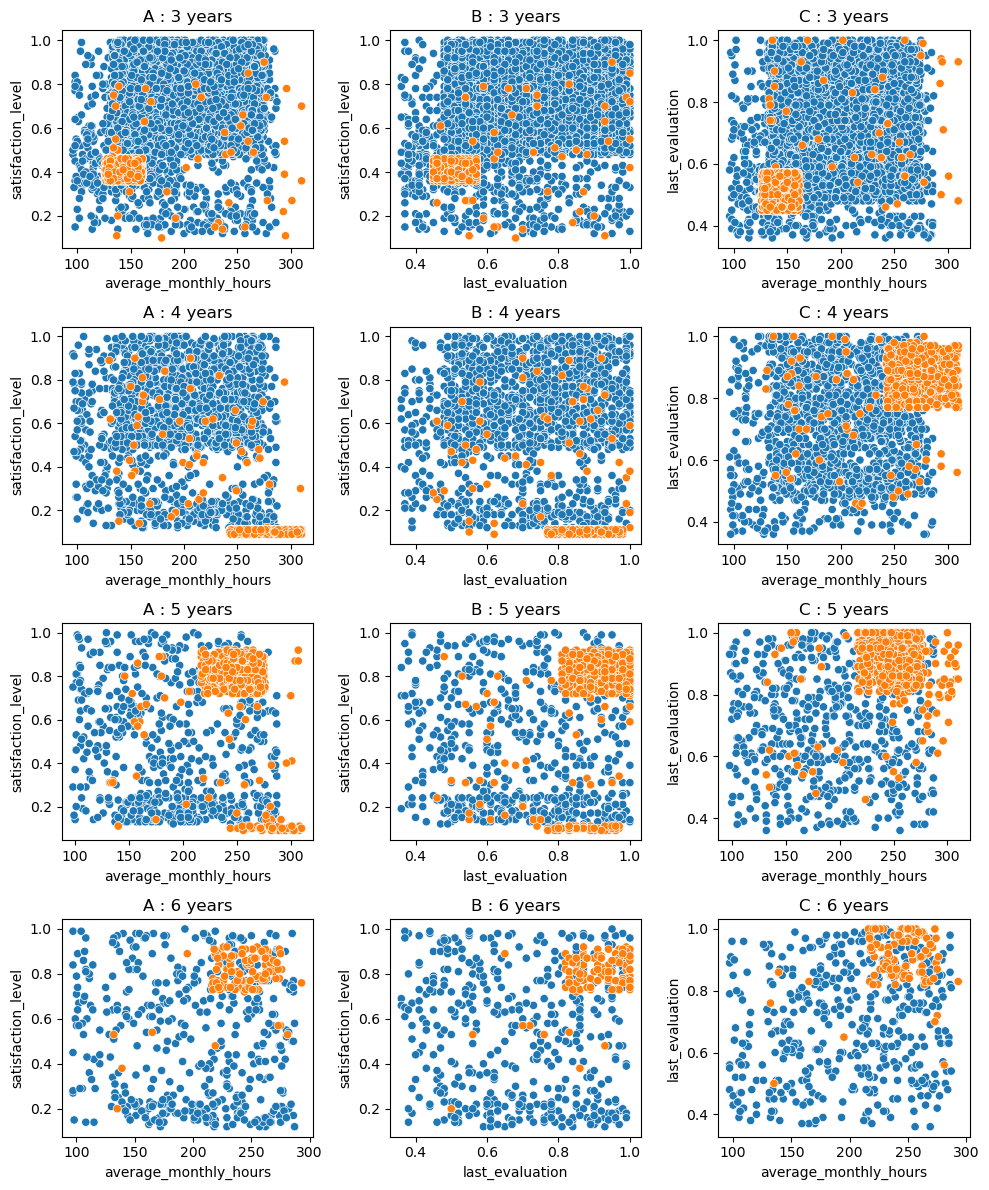

In [ ]:
# I will check now those years with high proportion of leaving employees with the scatter plots from before

years_in_the_company = [years_spent_3, years_spent_4, years_spent_5, years_spent_6]

fig, ax = plt.subplots(len(years_in_the_company), 3, figsize=(10, 3 * len(years_in_the_company)))

for i, years in enumerate(years_in_the_company):
    sns.scatterplot(data=data[years].sort_values('left'), x='average_monthly_hours', y='satisfaction_level', hue='left', ax=ax[i, 0], legend=False)
    ax[i, 0].set_title(f'A : {i+3} years')

    sns.scatterplot(data=data[years].sort_values('left'), x='last_evaluation', y='satisfaction_level', hue='left', ax=ax[i, 1], legend=False)
    ax[i, 1].set_title(f'B : {i+3} years')

    sns.scatterplot(data=data[years].sort_values('left'), x='average_monthly_hours', y='last_evaluation', hue='left', ax=ax[i, 2], legend=False)
    ax[i, 2].set_title(f'C : {i+3} years')

plt.tight_layout()
plt.show()


Now it seems clear what are the three groups from beafore of people who are leaving!

Employees after 3 years in the company who are unsatisfied and were identified as inefficient are most probably fired.

Year 4 is marked by employees who are completely unsatisfied with the fact that they work enourmous amounts of hours.

In the 5th year there seem to be both those who are unsatisfied with their working hours and those who are satisfied but still leave - potentially because of another better offer or lack of promotion

In the 6th year leaving employees are mostly satisfied and well evaluated however probably lacking recognition.




Another observation can be made for the employees in their 5th and 6th year - among those who stayed there is a high density on the lower bounds of satisfacton - this might be a red flag, that the company is not rewarding them for their long lasting cooperation.

<Axes: xlabel='time_spend_company', ylabel='Percent'>

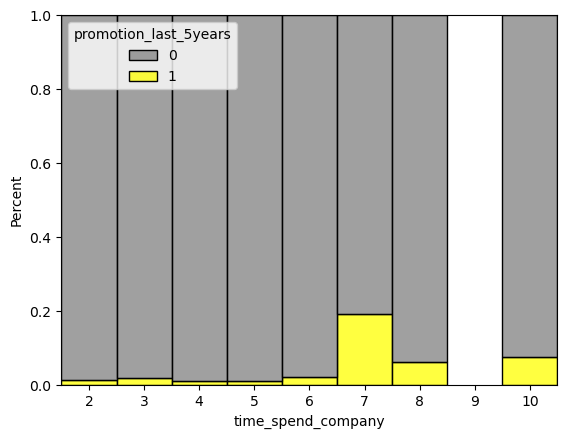

In [ ]:
# Checking after how many years employees get promoted 
# 
# It seems that mostly employees get promoted after 7 years or more in the company
#
# As seen previously the proportion of people leaving after 7 years in the comapny is 0% which might mean that recognition plays a big part for the workers

sns.histplot(data=data, x='time_spend_company', hue='promotion_last_5years', stat='percent', multiple='fill', discrete=True, palette={0: 'grey', 1:'yellow'})


<Axes: xlabel='salary', ylabel='Proportion'>

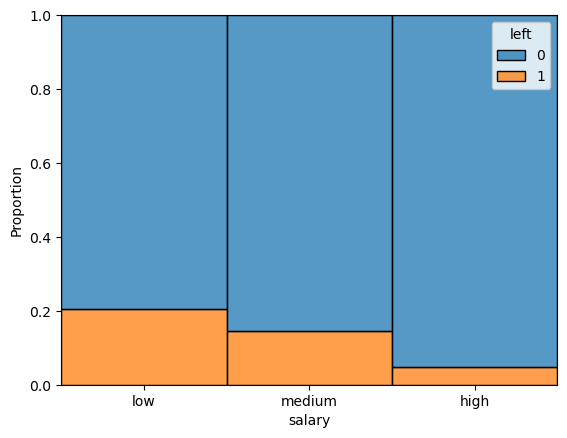

In [ ]:
# Another possible reason for leaving might be low salary, so I will look into that category
#
# Looking at the data it is reasonable to say that higher paid workers tend to stay 

sns.histplot(data=data, x='salary', hue='left', stat='proportion', discrete=True, multiple='fill')

In [23]:
low_salary = data['salary'] == 'low'

medium_salary = data['salary'] == 'medium'

high_salary = data['salary'] == 'high'

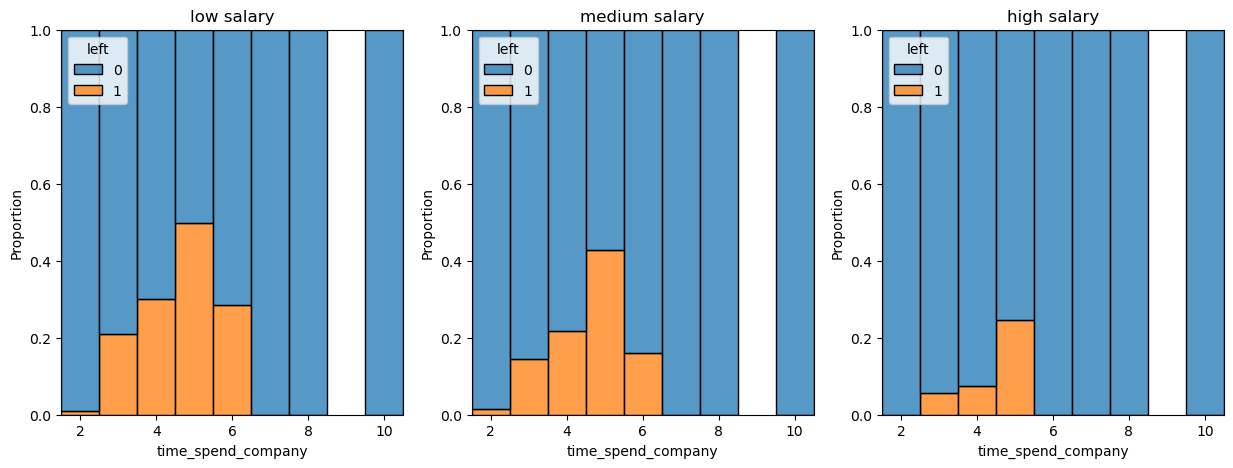

In [30]:
# Checking if there are some patterns between salary an number of years 
# 
# There are no strong connection between those two categories.
#
# Two observation that could be made are:
# 1. Even with high salaries people leave after five years and as seen from before those are skilled workers who work enourmous hours;
# 2. No employee with a high salary left after having spent 6 years in the company

salaries = [low_salary,medium_salary,high_salary]
salary_titles = ['low','medium', 'high']

fig, ax = plt.subplots(1,3, figsize=(15,5))

for i, salary in enumerate(salaries):
    sns.histplot(data=data[salary], x='time_spend_company', hue='left', multiple='fill', stat='proportion', discrete=True, ax=ax[i])
    ax[i].set_title(salary_titles[i] + ' salary')

plt.show()

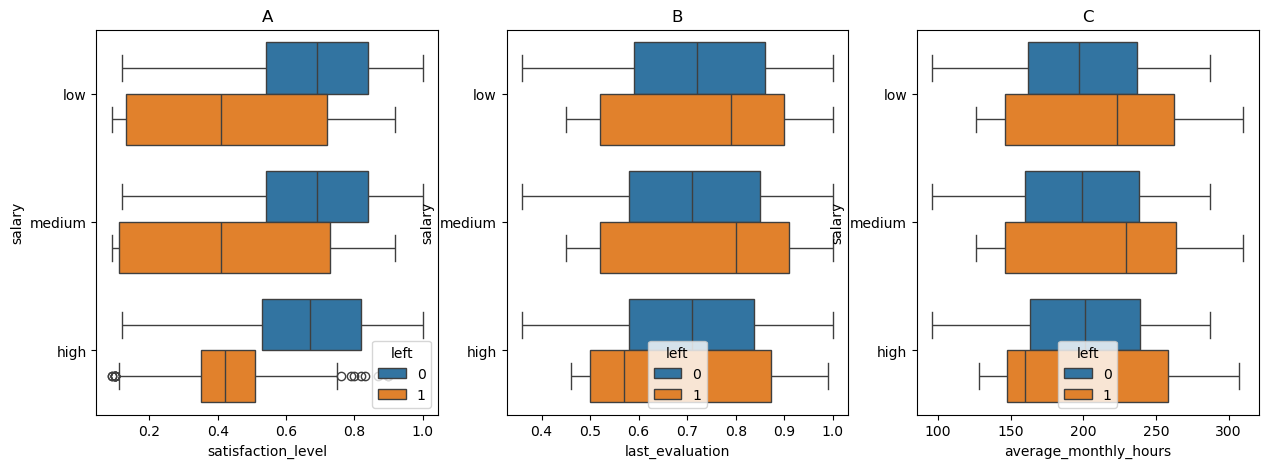

In [42]:
# There seems to be no much difference in relationships of salary categories to continous metrics in terms of proportion of employees who left. 
# Only the Satisfaction level were lower for those who left in all the salary groups


fig, ax = plt.subplots(1,3, figsize=(15,5))

letters =['A', 'B','C']

for i, column in enumerate(kde_columns):
    sns.boxplot(data=data, x=column, y='salary', hue='left', ax=ax[i])
    ax[i].set_title(letters[i])

plt.show()

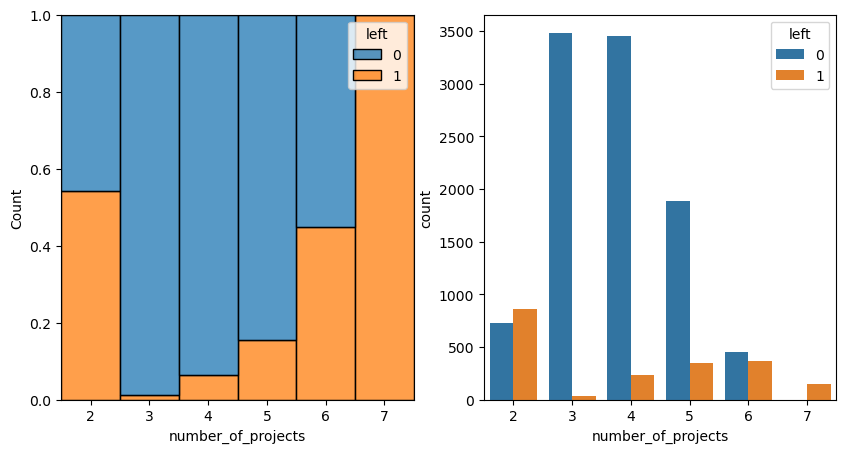

In [48]:
# Now I will check how number of projects is related to employees leaving rates
# 
# Workload must be one of the deciding factors of employees leaving the company. The best is to keep number of projects up to 4 per person.

fig, ax= plt.subplots(1,2, figsize=(10,5))

sns.histplot(data=data,x='number_of_projects', hue='left', multiple='fill', discrete=True, ax=ax[0])

sns.countplot(data=data, x='number_of_projects',hue='left',ax=ax[1])

plt.show()

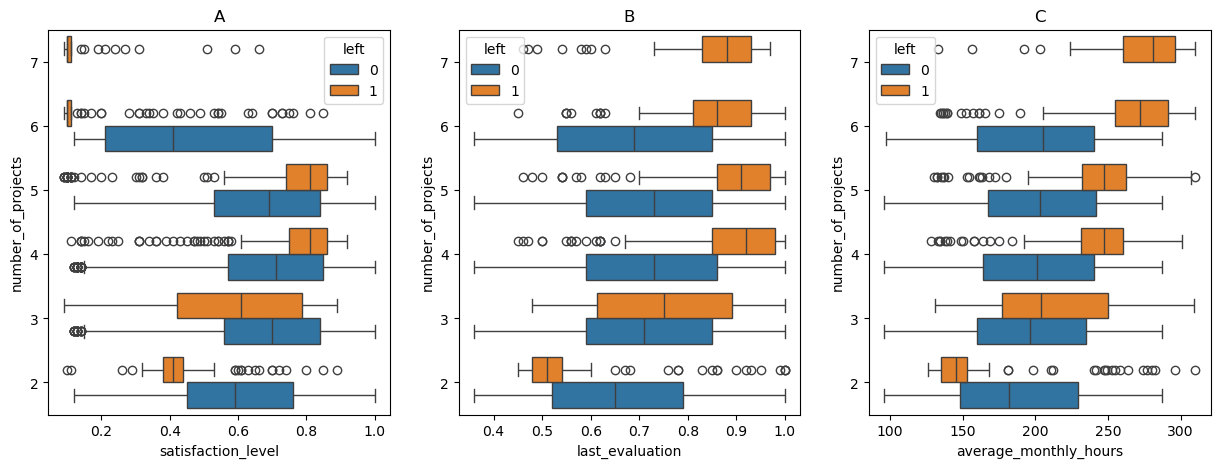

In [43]:
# Number of projects against continous metrics

fig, ax = plt.subplots(1,3, figsize=(15,5))



for i, column in enumerate(kde_columns):
    sns.boxplot(data=data, x=column, y='number_of_projects', hue='left', ax=ax[i], orient='h')
    ax[i].invert_yaxis()
    ax[i].set_title(letters[i])

plt.show()

Number of projects per employee is definitely one of the deciding factors for leaving.

Plot A: Employees who left with either 2 or 6 and more projects were less satisfied than their collegues. And even among those who stayed having six projects the satisfaction levels are considerably low. The company should reduce their workload, otherwise those employees are at risk of quitting.

Plot B: Except for employees with 2 or 3 projects, in all the other cases those who left were evaluated better than their collegues. Meaning they were probably the most skilled workers on those projects.

Plot C: It confirms the fact that those who left were contributing the most to their projects (among the employees working on 4 or more projects). 

Looking at employees with just 2 projects - those who left were mostly less skilled and worked less than their collegues. I would infer again that they were fired.  

#######################################################

# Building Models

#######################################################

For this Dataset it seems that Tree based model or K Nearest Neighbours would be most suitable

So I'll try both and I will crossvalidate them
1. KNN
2. XGBoost

In [151]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import xgboost as xgb

In [90]:
# Separating dependent variable

X, y = data.drop('left', axis=1), data['left']

In [91]:
# Splitting data into train and test fold

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.25, stratify=y, random_state=42)

In [92]:
# for KNN I need to scale the monthly hours column, because it ranges from 100 until 310, whereas all the rest is between 0 and 1
#
# And I need to encode the categorical columns with text 

preprocessing = ColumnTransformer(transformers=[('categorical', OneHotEncoder(), ['department', 'salary']),
                                                ('scaling', MinMaxScaler(), ['average_monthly_hours'])], 
                                                remainder='passthrough')

In [93]:
# Pipelin

knn_pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('knn', KNeighborsClassifier())
])

knn_pipe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(),
                                                  ['department', 'salary']),
                                                 ('scaling', MinMaxScaler(),
                                                  ['average_monthly_hours'])])),
                ('knn', KNeighborsClassifier())])

In [94]:
# hyperparameters to test

knn_params = {
    'knn__n_neighbors' : [5,10,20],
    'knn__weights' : ['uniform', 'distance']
}

In [95]:
# Standard scoring for the classification tasks 

scoring = ['precision', 'accuracy', 'recall', 'f1']

In [96]:
# Crossvalidation with different hyperparameters
#
# I prioritize the F1 score to keep the balance between recall and precision

knn_grid = GridSearchCV(knn_pipe, knn_params, scoring=scoring, cv=3, refit='f1')

In [97]:
# Fitting the model

knn_grid.fit(X_train, y_train)

c:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('categorical',
                                                                         OneHotEncoder(),
                                                                         ['department',
                                                                          'salary']),
                                                                        ('scaling',
                                                                         MinMaxScaler(),
                                                                         ['average_monthly_hours'])])),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [5, 10, 20],
                         'knn__weights': ['uniform', 'distance']},
             refit='f1', scoring=['precision', 'accuracy', 'recall', 'f1'])

In [98]:
# The refitted to f1 score model is not so good at precision rankwise but the actual difference is not so big

pd.DataFrame(knn_grid.cv_results_).sort_values('rank_test_f1')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,param_knn__weights,params,split0_test_precision,split1_test_precision,split2_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_recall,split1_test_recall,split2_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,mean_test_f1,std_test_f1,rank_test_f1
3,0.014362,0.001291,0.051016,0.001340,10,distance,"{'knn__n_neighbors': 10, 'knn__weights': 'dist...",0.815642,0.808824,0.804428,0.809631,0.004614,1,0.946965,0.945964,0.944278,0.945735,0.001109,1,0.879518,0.883534,0.877264,0.880105,0.002593,1,0.846377,0.844530,0.839269,0.843392,0.003011,1
1,0.014265,0.002177,0.048855,0.003180,5,distance,"{'knn__n_neighbors': 5, 'knn__weights': 'dista...",0.815642,0.800000,0.811918,0.809187,0.006672,2,0.946965,0.941961,0.945946,0.944957,0.002159,2,0.879518,0.867470,0.877264,0.874751,0.005230,3,0.846377,0.832370,0.843327,0.840691,0.006014,2
5,0.018394,0.003181,0.089941,0.017350,20,distance,"{'knn__n_neighbors': 20, 'knn__weights': 'dist...",0.794545,0.784698,0.779174,0.786139,0.006358,5,0.941961,0.940627,0.937938,0.940175,0.001673,3,0.877510,0.885542,0.873239,0.878764,0.005100,2,0.833969,0.832075,0.823529,0.829858,0.004541,3
0,0.014527,0.001552,0.055298,0.010905,5,uniform,"{'knn__n_neighbors': 5, 'knn__weights': 'unifo...",0.794063,0.796190,0.809339,0.799864,0.006756,4,0.939626,0.937625,0.940274,0.939175,0.001127,4,0.859438,0.839357,0.837022,0.845272,0.010062,4,0.825458,0.817204,0.822948,0.821870,0.003455,4
2,0.014177,0.001785,0.049973,0.001129,10,uniform,"{'knn__n_neighbors': 10, 'knn__weights': 'unif...",0.808679,0.811024,0.798371,0.806024,0.005496,3,0.938292,0.939293,0.931932,0.936506,0.003260,5,0.823293,0.827309,0.788732,0.813112,0.017316,5,0.815920,0.819085,0.793522,0.809509,0.011378,5
4,0.020848,0.003571,0.065845,0.007040,20,uniform,"{'knn__n_neighbors': 20, 'knn__weights': 'unif...",0.765049,0.755382,0.757741,0.759390,0.004115,6,0.924950,0.920947,0.928595,0.924831,0.003123,6,0.791165,0.775100,0.837022,0.801096,0.026237,6,0.777887,0.765114,0.795411,0.779471,0.012419,6


In [99]:
knn_grid.best_score_

0.8433916965014235

In [100]:
knn_grid.best_params_

{'knn__n_neighbors': 10, 'knn__weights': 'distance'}

In [ ]:
# Checking how the KNN model performs on the test set

knn_pred = knn_grid.predict(X_test)

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2500
           1       0.81      0.89      0.85       498

    accuracy                           0.95      2998
   macro avg       0.90      0.93      0.91      2998
weighted avg       0.95      0.95      0.95      2998



Text(0.5, 1.0, 'KNN Classifier')

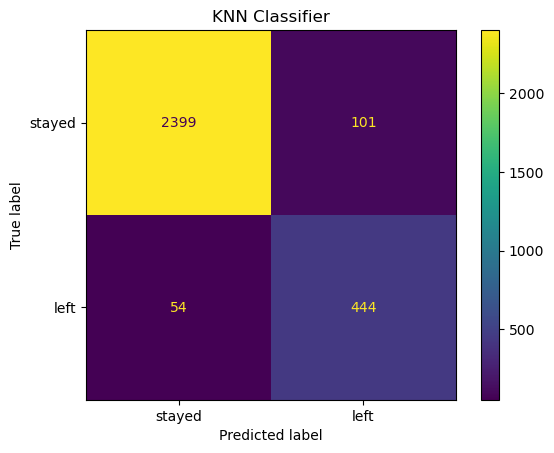

In [122]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, knn_pred), display_labels=['stayed', 'left']).plot()
plt.title('KNN Classifier')

The scores are quite good for this model - it predicted correctly 89% of those who left, however it also labels many people who stayed as if they were leaving - my assumption would be that it classifies also the people with 6 project as leaving because of their low satisfaction levels.

It seems this model is not overfitting and not underfitting. It makes more a Type 1 error or False Positives - it labels someone as leaving when in fact this person is not - which means that if the management uses this model they might prevent person from wanting to leave in the future.

In [127]:
# Next Model - XGBoost

# Tree based model do not require scaling so I'll remove it

xgb_preprocessing = ColumnTransformer(transformers=[('categorical', OneHotEncoder(), ['department', 'salary'])], 
                                                remainder='passthrough')

xgb_pipe = Pipeline([
    ('preprocessing', xgb_preprocessing),
    ('xgb', XGBClassifier(objective='binary:logistic'))
])

# As hyparameters I chose to reduce how many features is taken by each tree, and increasing the number of trees to compensate for it.

xgb_params = {'xgb__colsample_bytree': [0.5,1],
          'xgb__n_estimators' : [100,300]}

xgb_grid = GridSearchCV(xgb_pipe, xgb_params, scoring=scoring, refit='f1')

In [128]:
xgb_grid.fit(X_train,y_train)

c:\Anaconda\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('categorical',
                                                                         OneHotEncoder(),
                                                                         ['department',
                                                                          'salary'])])),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_c...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=None, ...))]),
             param_grid={'xgb__colsample_bytree': [0.5, 1],
                         'xgb__n_estimators': [100, 300]},
             refit='f1', scoring=['precision', 'accuracy', 'recall', 'f1'])

In [114]:
pd.DataFrame(xgb_grid.cv_results_).sort_values('rank_test_f1')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgb__colsample_bytree,param_xgb__n_estimators,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,split4_test_precision,mean_test_precision,std_test_precision,rank_test_precision,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_recall,split1_test_recall,split2_test_recall,split3_test_recall,split4_test_recall,mean_test_recall,std_test_recall,rank_test_recall,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,split4_test_f1,mean_test_f1,std_test_f1,rank_test_f1
0,0.089529,0.037617,0.015609,0.003533,0.5,100,"{'xgb__colsample_bytree': 0.5, 'xgb__n_estimat...",0.971631,0.972125,0.951724,0.981949,0.971631,0.969812,0.009864,2,0.981656,0.984436,0.979433,0.982759,0.982202,0.982097,0.001625,1,0.916388,0.933110,0.923077,0.912752,0.919463,0.920958,0.006966,1,0.943201,0.952218,0.937182,0.946087,0.944828,0.944703,0.004842,1
2,0.052974,0.001011,0.012203,0.000529,1.0,100,"{'xgb__colsample_bytree': 1, 'xgb__n_estimator...",0.975177,0.975524,0.967857,0.978261,0.964912,0.972346,0.005070,1,0.982768,0.984992,0.979433,0.981090,0.981646,0.981986,0.001848,2,0.919732,0.933110,0.906355,0.906040,0.922819,0.917611,0.010319,2,0.946644,0.953846,0.936097,0.940767,0.943396,0.944150,0.005952,2
1,0.146414,0.018781,0.012621,0.000526,0.5,300,"{'xgb__colsample_bytree': 0.5, 'xgb__n_estimat...",0.971429,0.958763,0.951049,0.971223,0.968198,0.964132,0.008001,3,0.980545,0.982212,0.977210,0.979978,0.981646,0.980318,0.001743,3,0.909699,0.933110,0.909699,0.906040,0.919463,0.915602,0.009824,3,0.939551,0.945763,0.929915,0.937500,0.943201,0.939186,0.005446,3
3,0.138007,0.003876,0.013224,0.001080,1.0,300,"{'xgb__colsample_bytree': 1, 'xgb__n_estimator...",0.971631,0.959044,0.964158,0.957447,0.957746,0.962005,0.005385,4,0.981656,0.983324,0.977765,0.977753,0.978865,0.979873,0.002238,4,0.916388,0.939799,0.899666,0.906040,0.912752,0.914929,0.013692,4,0.943201,0.949324,0.930796,0.931034,0.934708,0.937813,0.007299,4


In [115]:
xgb_grid.best_score_

0.9447032027072189

In [116]:
xgb_grid.best_params_

{'xgb__colsample_bytree': 0.5, 'xgb__n_estimators': 100}

In [117]:
xgb_pred = xgb_grid.predict(X_test)

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.97      0.93      0.95       498

    accuracy                           0.98      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



Text(0.5, 1.0, 'XGB Classifier')

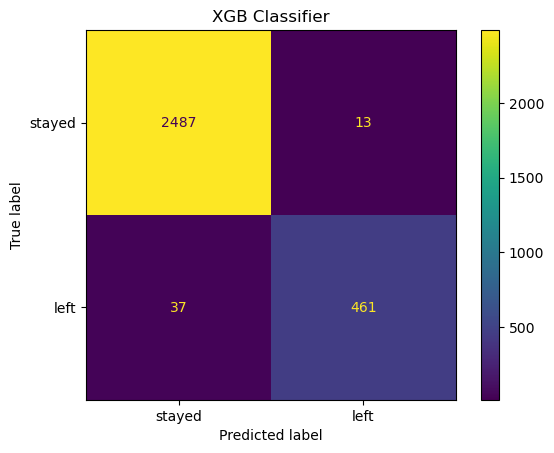

In [121]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, xgb_pred), display_labels=['stayed', 'left']).plot()

plt.title('XGB Classifier')

XGBoost performed better both on training and test sets. Over every score it is better than KNN. Now I will look into what features it considers most important 

In [133]:
gini_scores = xgb_grid.best_estimator_.named_steps['xgb'].feature_importances_

In [130]:
features = xgb_grid.best_estimator_.named_steps['preprocessing'].get_feature_names_out()

In [145]:
df_importances = pd.DataFrame(data=gini_scores, index=features).reset_index(names='feature')

<Axes: xlabel='0', ylabel='feature'>

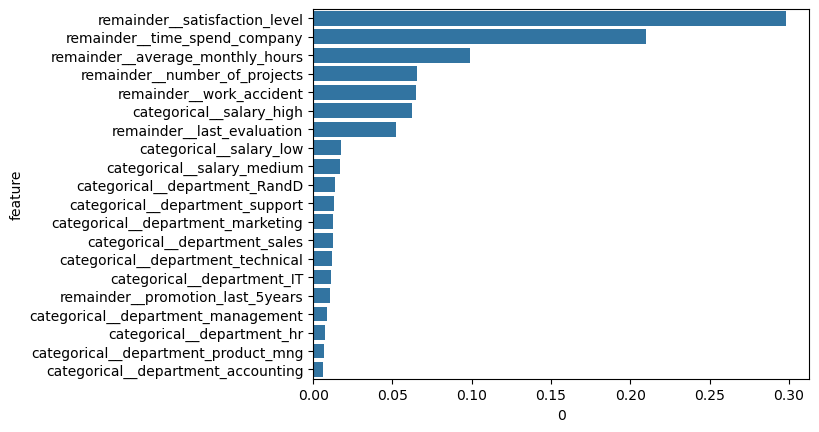

In [149]:
sns.barplot(data=df_importances.sort_values(0,ascending=False), x=0, y='feature')

The model considers following features the most important for identification of an employee leaving the company or not: satisfaction, time spent in the company, monthly hours, number of projects, whether or not an employee had work accident, salary and evaluation.

As seen in the exploratory phase - those who leave have lower satisfaction of average. However, satisfaction is influenced by other factors, so we want to predict if a person is leaving before her satisfaction level drops.

Those who are for 7 or more years in the company have not left in the past, so the model most probably caught that as well.

Monthly hours and number of projects are as I inferred before quite important in estimating.

Most of those who had an accident at work stayed, so i suppose the model considers this feature important because so few with an accident left.

High salary - we've seen that those with higher salaries mostly stay.

And last evaluation score - as seen from the scatter plots before there are two big groups of employees who leave - with really high score and with really low scores. 


In [ ]:
# As each colsample_bytree is 0.5 it means that each tree chooses randomly only a half of all the features, so there is no one tree with all the features.
# I will visualise some of the trees from XGBoost to see how it classifies the entries
#
# for the names of the features xgb.plot_tree requires an .fmap file

feature_map = [
    (0, "categorical__department_IT", "q"),
    (1, "categorical__department_RandD", "q"),
    (2, "categorical__department_accounting", "q"),
    (3, "categorical__department_hr", "q"),
    (4, "categorical__department_management", "q"),
    (5, "categorical__department_marketing", "q"),
    (6, "categorical__department_product_mng", "q"),
    (7, "categorical__department_sales", "q"),
    (8, "categorical__department_support", "q"),
    (9, "categorical__department_technical", "q"),
    (10, "categorical__salary_high", "q"),
    (11, "categorical__salary_low", "q"),
    (12, "categorical__salary_medium", "q"),
    (13, "remainder__satisfaction_level", "float"),
    (14, "remainder__last_evaluation", "float"),
    (15, "remainder__number_of_projects", "float"),
    (16, "remainder__average_monthly_hours", "float"),
    (17, "remainder__time_spend_company", "q"),
    (18, "remainder__work_accident", "q"),
    (19, "remainder__promotion_last_5years", "q"),
]

# Write to a .fmap file
with open("salisfort_feature_map.fmap", "w") as f:
    for idx, name, ftype in feature_map:
        f.write(f"{idx} {name} {ftype}\n")

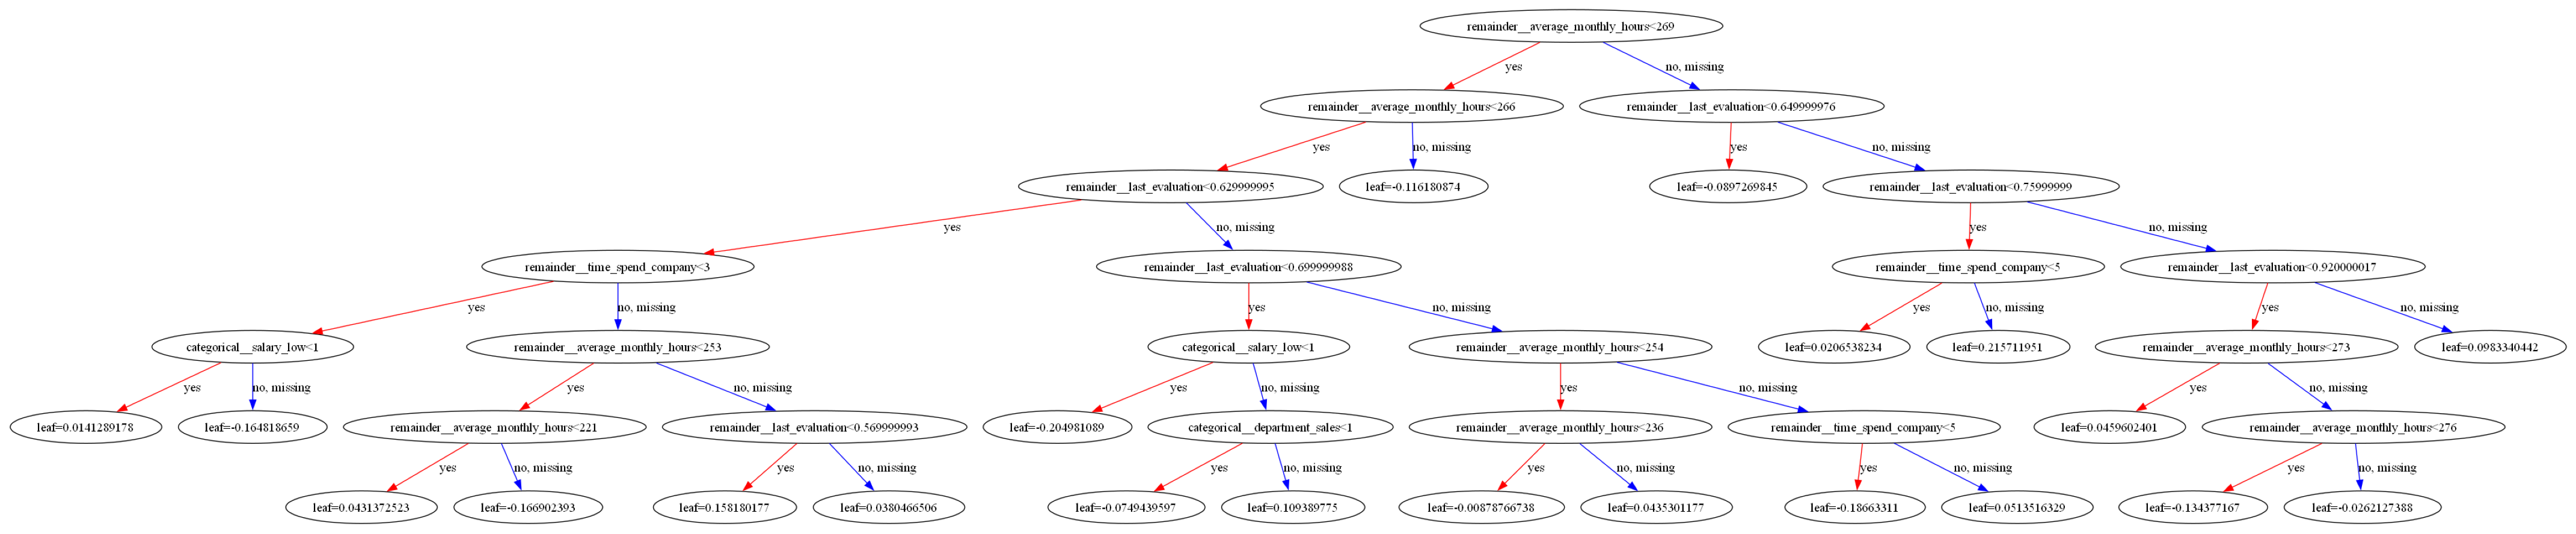

In [ ]:
# The leaf value is representative (like raw score) for the probability of the data point belonging to the positive class,
# The leaf value (raw score) can be negative or positive, the value 0 actually represents probability being 1/2.

# This tree considers monthly hours and evaluation score as primary deciding factors 

fig, ax=plt.subplots(figsize=(50,50),dpi=110)

xgb.plot_tree(xgb_grid.best_estimator_.named_steps['xgb'], num_trees=99, ax=ax, fmap = 'salisfort_feature_map.fmap')

plt.show()

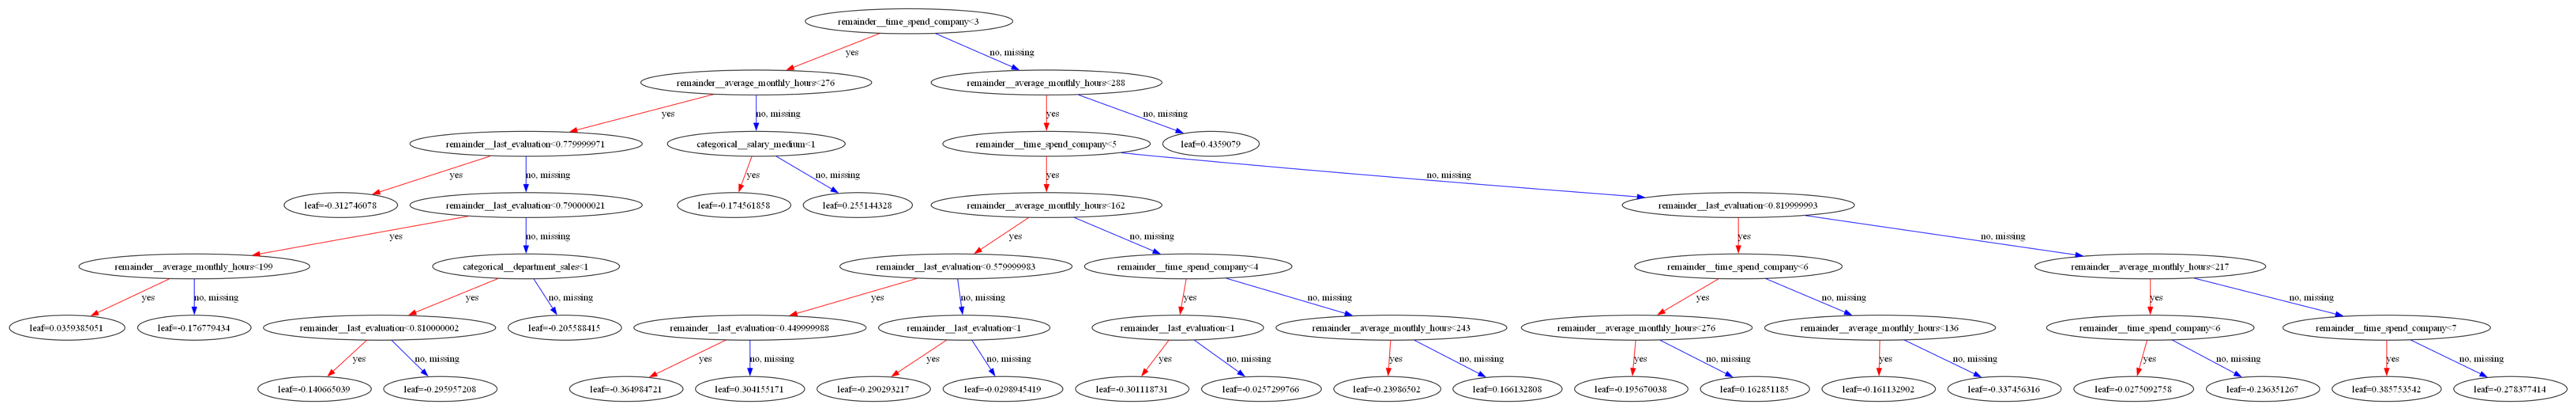

In [ ]:
# This tree takes the number of years in the company as its starting point

fig, ax=plt.subplots(figsize=(50,50),dpi=110)

xgb.plot_tree(xgb_grid.best_estimator_.named_steps['xgb'], num_trees=4, ax=ax, fmap = 'salisfort_feature_map.fmap')

plt.show()

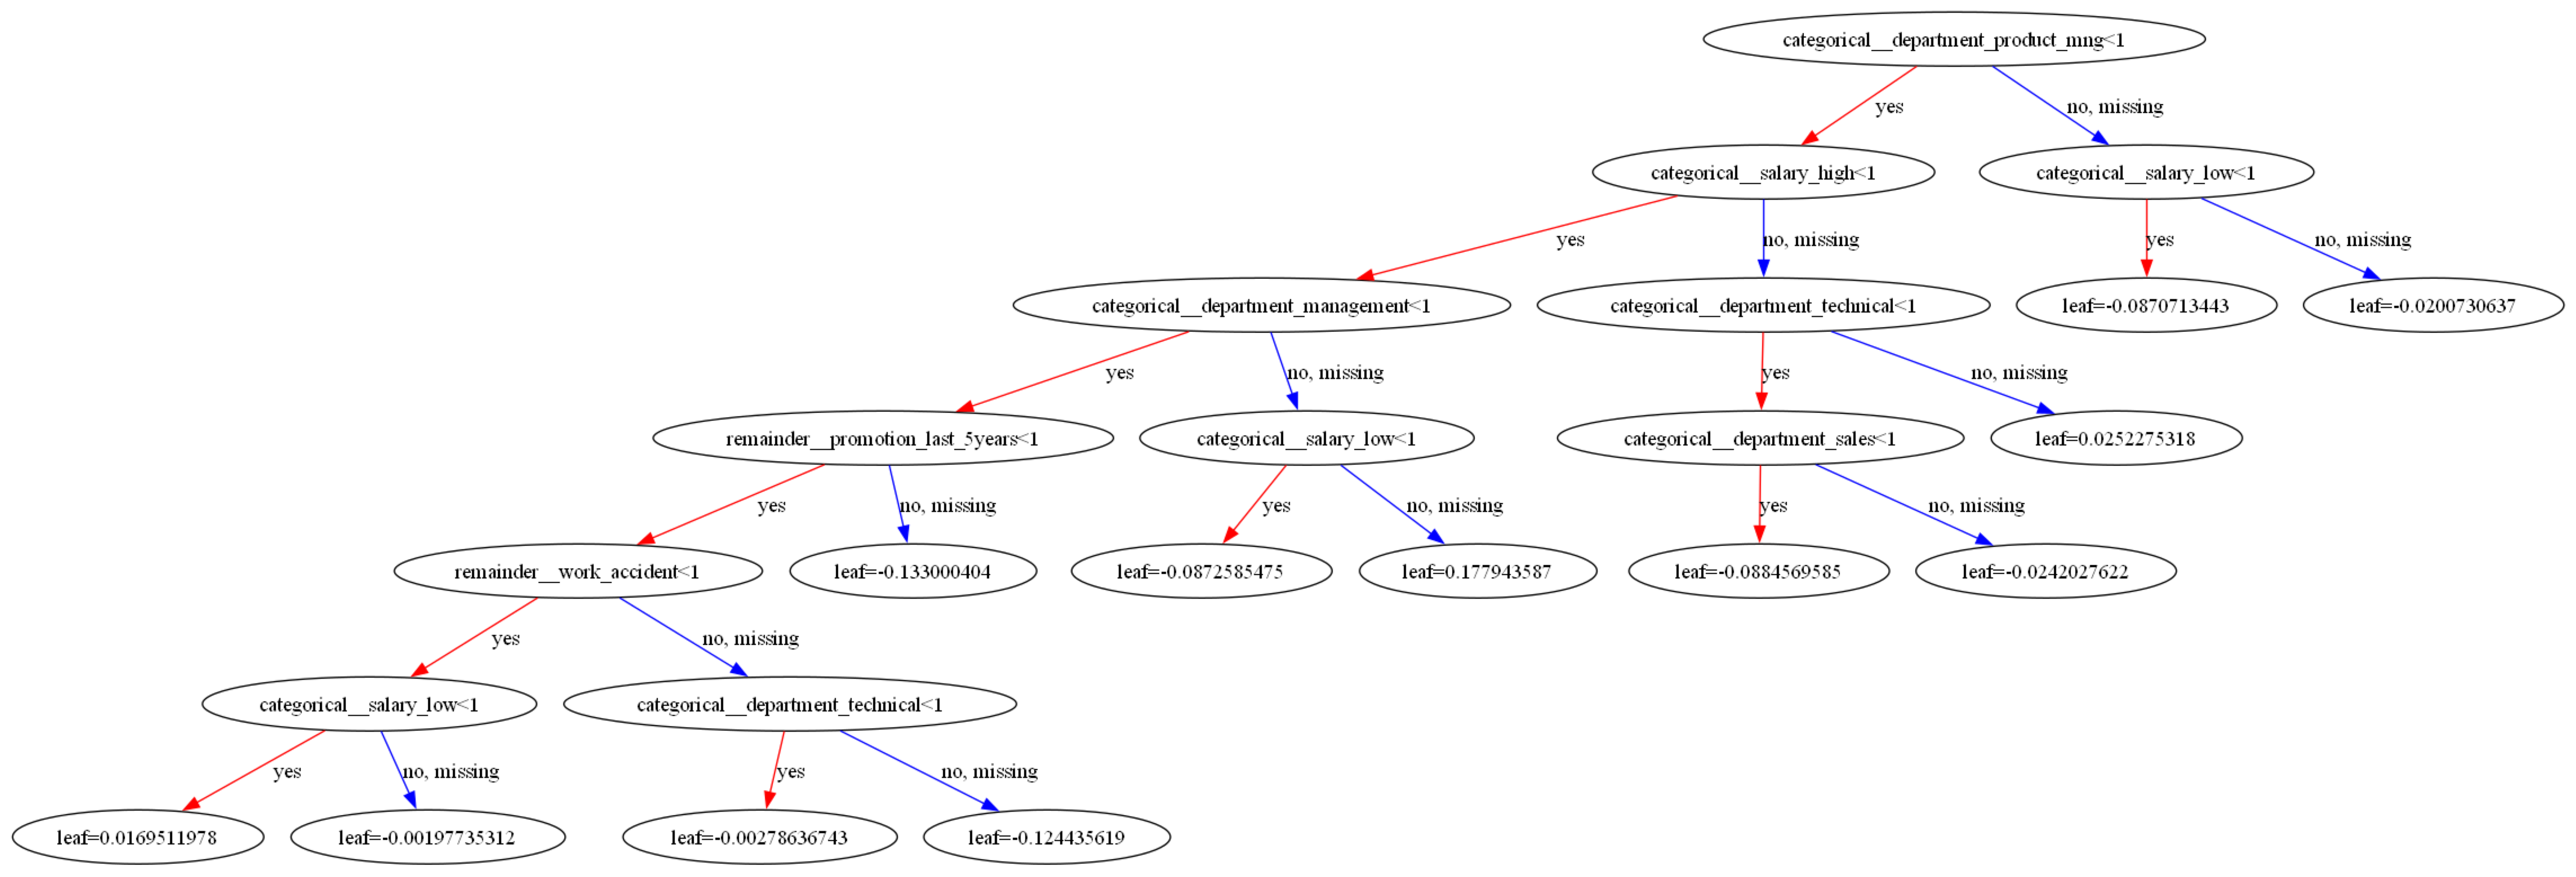

In [ ]:
# This tree does not have very strong leaf scores, it starts off with department classification, but as it was seen before this is not a strong prediction feature

fig, ax=plt.subplots(figsize=(50,50),dpi=110)

xgb.plot_tree(xgb_grid.best_estimator_.named_steps['xgb'], num_trees=50, ax=ax, fmap = 'salisfort_feature_map.fmap')

plt.show()

### ML Models conclusion

XGBoost Classifier performs better with the recall score of 93%. To remain sceptical of overfitting, it is good to use KNN, however given the nature of the dataset and previous findings it seems reasonable that there are quite specific groups of employees leaving, thus I would still recommend the XGB model.

KNN model gives more errors, predicting some employees leaving when they are not, so for the management that does not have resources to support more employees at moderate risk of leaving but instead wants to support only those who are at higher risk of leaving, the XGB model will remain more efficient.



###########################################



# Summary

### Key Findings

- 16.6% of employees left the company
- Skilled employees who work longer hours with 4 or more projects quit - they were probably contributing the most to the projects
- Poorly evaluated employees working less hours than their collegues are probably getting fired or they have reduced their hours after having decided to leave
- Groups of workers with 3 to 4 projects have the smallest proportions of leaving employees

### Recommendations

- Limit the number of projects to 4 per employee
- Reduce working hours to a maximum of 205 per month and/or reward those contributing more
- Use the ML model to identify employees at risk of leaving
- Add a column to the dataset mentioning if the person was fired or left on her own

## Plots for Executive Summary Report

Executive summary must be short, concise and reveal my findings.

From the book of Cole Nussbaumer Knaflic 'Storytelling with Data' I learned to show the findings and not the exploratory process, so I will showcase the most relevant findings that management team can implement right away and if not agreeing with my recommendation it might bring important discussions.

The final document was assembled in Canva and can be found in GitHub folder.

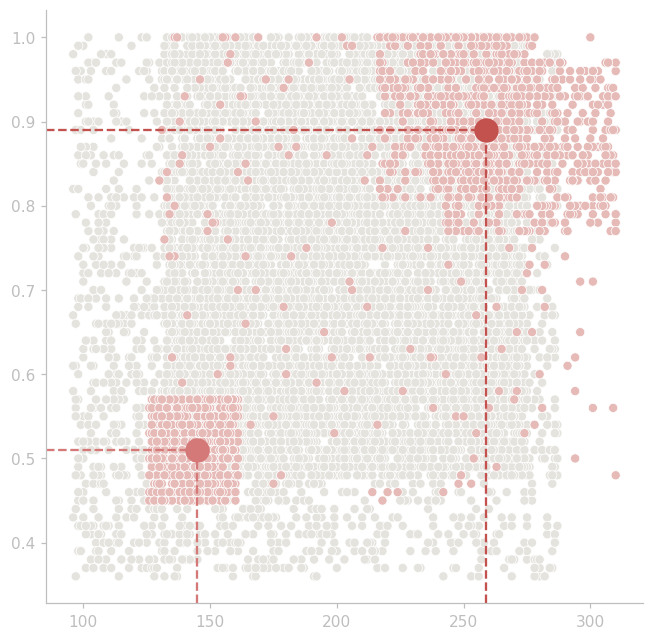

In [98]:
sns.color_palette('deep')

fig, ax= plt.subplots(figsize=(7,7), dpi=110)

ax = sns.scatterplot(data=data.sort_values('left'), x='average_montly_hours', y='last_evaluation', 
                hue='left', legend=None, palette={0:'#E5E3DE', 1:'#E6BAB7'})

for tick_label in ax.axes.get_yticklabels():
    tick_label.set_color('#BFBEBE')

for tick_label in ax.axes.get_xticklabels():
    tick_label.set_color('#BFBEBE')

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

for spine in ['bottom','left']:
    ax.spines[spine].set_color('#BFBEBE')

ax.tick_params(color='#BFBEBE')

ax.set_xlabel('')

ax.set_ylabel('')

ax.scatter(x=259, y=0.89, color='#C3514E', linewidths=10)

ax.scatter(x=145.0, y=0.51, color='#d47977',linewidths=10)

ax.axvline(x=259, ymax=0.80, color='#C3514E', ls='--')

ax.axvline(x=145, ymax=0.25, color='#d47977',ls='--')

ax.axhline(y=0.89, xmax=0.75, color='#C3514E',ls='--')

ax.axhline(y=0.51, xmax=0.25, color='#d47977',ls='--')


plt.show()

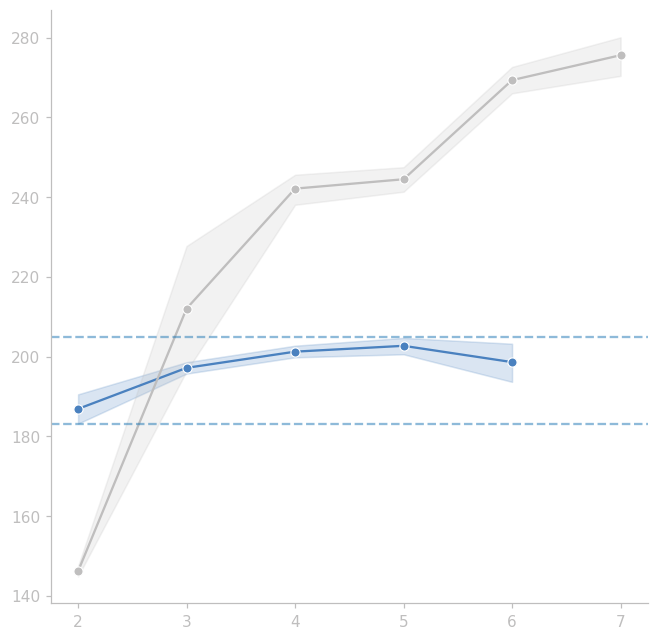

In [157]:
fig, ax = plt.subplots(figsize=(7,7),dpi=110)

ax = sns.lineplot(data=data, x='number_project',y='average_montly_hours', hue='left', marker='o', palette={0:'#4A81BF', 1:'#BFBEBE'}, legend=False)

for tick_label in ax.axes.get_yticklabels():
    tick_label.set_color('#BFBEBE')

for tick_label in ax.axes.get_xticklabels():
    tick_label.set_color('#BFBEBE')

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

for spine in ['bottom','left']:
    ax.spines[spine].set_color('#BFBEBE')

ax.tick_params(color='#BFBEBE')

ax.set_xlabel('')

ax.set_ylabel('')

ax.axhline(y=205, ls='--', alpha=0.5)
ax.axhline(y=183, ls='--', alpha=0.5)


plt.show()

In [178]:
mask = data.groupby('number_of_projects')['left'].value_counts(normalize=True).reset_index()['left'] == 1

data.groupby('number_of_projects')['left'].value_counts(normalize=True).reset_index()[mask].reset_index(drop=True)


,number_of_projects,left,proportion
0,2,1,0.541719
1,3,1,0.010795
2,4,1,0.064315
3,5,1,0.153605
4,6,1,0.449153
5,7,1,1.000000


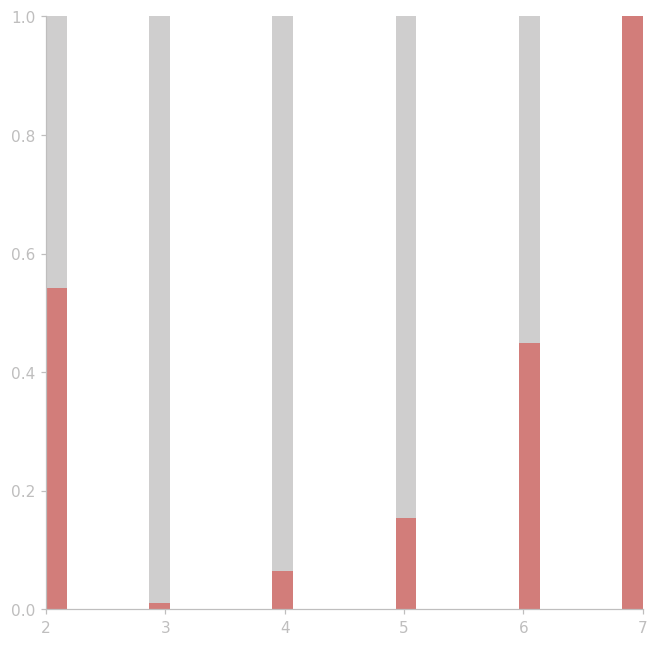

In [158]:
fig, ax = plt.subplots(figsize=(7,7),dpi=110)
ax = sns.histplot(data=data, x='number_project', hue='left', multiple='fill', stat='percent',
                  palette={0:'#BFBEBE', 1:'#C3514E'}, legend=False, ec=None)

for tick_label in ax.axes.get_yticklabels():
    tick_label.set_color('#BFBEBE')

for tick_label in ax.axes.get_xticklabels():
    tick_label.set_color('#BFBEBE')

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

for spine in ['bottom','left']:
    ax.spines[spine].set_color('#BFBEBE')

ax.tick_params(color='#BFBEBE')

ax.set_xlabel('')

ax.set_ylabel('')

plt.show()